# پیش‌بینی قیمت سهم در تاریخ سررسید — بورس اوراق بهادار تهران (v1)
### Price-at-Maturity Forecasting for TSE Covered-Call Underlyings

**هدف این نوت‌بوک** با نسخه‌ی قبلی پروژه (`covered_call_strategy.ipynb`) اساساً فرق دارد:

- نسخه‌ی قبلی یک مدل **کلاسیفیکیشن** آموزش می‌داد («احتمال صعود/نزول تا افق ثابت ۵ روزه»)
  که خروجی‌اش فقط برای گیتِ فروش/عدم‌فروش کال در بک‌تست استفاده می‌شد؛ هیچ پیش‌بینیِ
  عددیِ قیمت وجود نداشت. AUCهای واقعی آن (طبق `horizon_selection_summary.csv` موجود در
  ریپازیتوری) هم اغلب نزدیک ۰.۵ (تصادف) بودند.
- **این نسخه** مستقیماً روی هدف اصلیِ کاربر تمرکز می‌کند: **پیش‌بینیِ سطح قیمتِ سهم در
  خودِ تاریخ سررسید** (Maturity Date) — همان چیزی که برای طراحیِ واقعیِ استراتژیِ
  کاورد کال (تعیینِ Strike، برآوردِ سود/زیانِ اختیار، و تصمیمِ نگه‌داشتن/فروش) واقعاً
  لازم است.

**دامنه‌ی این نسخه (طبق درخواست):** فقط تا مرحله‌ی «پیش‌بینیِ دقیقِ قیمت در سررسید»
پیش می‌رویم؛ اتصالِ این پیش‌بینی‌ها به موتورِ کاملِ بک‌تستِ کاورد کال (فرمول بلک-شولز،
انتخابِ Strike/Premium، محاسبه‌ی Sharpe/Sortino) به نسخه‌ی بعدی موکول می‌شود.

## چرا این‌طور طراحی شده — خلاصه‌ی روش‌شناسی حرفه‌ای

| مسئله | چالشِ بازار ایران | راه‌حلِ به‌کاررفته |
|---|---|---|
| هدف پیش‌بینی | قیمت سهم نوسانِ زیادی دارد و سطح خامِ آن Non-Stationary است | به‌جای پیش‌بینیِ مستقیمِ قیمت، **بازدهِ لگاریتمیِ تجمعیِ H روزه** پیش‌بینی می‌شود؛ قیمت سررسید از رابطه‌ی $\hat P_{t+H}=P_t\cdot e^{\hat r}$ بازسازی می‌شود (استاندارد در مالیِ کمّی). |
| جهش‌های قیمتیِ افراطی | افزایش سرمایه/تجدید ارزیابی در TSETMC جهش‌های ۳۰٪ تا ۹۰٪+ ایجاد می‌کند که ربطی به نوسانِ بازار ندارد | **Back-Adjustment وقایعِ شرکتی** (همان ایده‌ای که در نسخه‌ی قبلیِ پروژه به‌درستی اضافه شده بود، اینجا هم حفظ شده). |
| نوسانِ شدید/رژیم‌های متفاوت | بورس تهران در ۱۵ سال اخیر چند رژیمِ کاملاً متفاوتِ تورمی/رکودی را رد کرده | فیچرِ **نوسانِ شرطیِ GARCH(1,1)-t** (برازش‌شده فقط روی داده‌ی Train)، **وزن‌دهیِ نمایی به‌نفعِ داده‌ی جدید** (Recency Weighting)، و فیچرهای کلانِ **نرخ دلار آزاد**. |
| نشتِ داده (Leakage) | هدف H روز جلوتر را می‌بیند؛ بدون احتیاط، مرزِ Train/Val/Test نشت می‌دهد | **Purged Split با Embargo Gap = H روز** بینِ هر دو بخش (دقیقاً همان اصلِ Purged Cross-Validation در کتابِ *Advances in Financial Machine Learning*, López de Prado 2018). |
| انتخابِ افقِ سررسید | افقِ ثابتِ ۵ روزه در نسخه‌ی قبلی کاملاً دلبخواهی بود | **تورنمنتِ افق** روی چند افقِ کاندید (۱۰/۱۵/۲۰/۳۰ روزِ معاملاتی) با معیارِ Skill نسبت به یک baseline ساده، روی Walk-Forward Purged Folds — فقط از داده‌ی پیش از Test استفاده می‌شود (نه cherry-picking روی Test). |
| مدل‌های قوی | یک مدلِ تکی معمولاً بی‌ثبات است | مجموعه‌ای از baselineهای کلاسیک مالی (Random Walk، Drift، GBM با نوسانِ GARCH) + مدل‌های یادگیریِ ماشین (Ridge، LightGBM، XGBoost، CatBoost، RandomForest) + یک **LSTM+Attention** (PyTorch) + یک **Ensemble با وزن‌دهیِ اعتبارسنجی‌شده** (Forecast Combination، ایده‌ی Bates & Granger 1969) که اگر مدل‌های ML چیزی روی baseline اضافه نکنند، خودکار به baseline برمی‌گردد. |
| عدمِ‌قطعیت | یک عددِ تکی برای قیمتِ سررسید در بازارِ پرنوسان گمراه‌کننده است | **رگرسیونِ کوانتایل** (۱۰٪/۵۰٪/۹۰٪) با LightGBM → بازه‌ی پیش‌بینیِ قیمتِ سررسید، نه فقط یک نقطه. |
| صداقتِ علمی | انتخابِ مدل روی Test = Data Snooping | مدلِ «پیشنهادی» برای هر سهم فقط بر اساسِ **Validation RMSE** انتخاب می‌شود؛ Test فقط یک‌بار در پایان، صرفاً برای گزارش، لمس می‌شود. یک تست Walk-Forward Robustness (تشخیصی) هم پایداریِ نتیجه را نشان می‌دهد. |

**الهام‌گیری از ادبیاتِ حرفه‌ای:** ترکیبِ درخت‌های گرادیان‌بوست + شبکه‌ی توالی برای
پیش‌بینیِ مالی (Kim & Won, 2018 — hybrid GARCH-LSTM)، Purged/Embargoed Cross-Validation
(López de Prado, 2018)، اهمیتِ baselineهای Random-Walk/Drift در پیش‌بینیِ قیمت
(Meese & Rogoff puzzle در ادبیاتِ ارز/سهام)، و رگرسیونِ کوانتایل برای کمّی‌سازیِ ریسک در
بازارهای نوظهور با نوسانِ بالا.

⚠️ **صداقتِ علمی، دقیقاً مثلِ نسخه‌ی قبلیِ پروژه:** نتایج هرچه باشند (حتی اگر یک
baseline ساده برنده شود) دقیقاً همان‌طور که به‌دست آمده گزارش می‌شوند — این خودش
برای بازارِ تهران یک یافته‌ی معتبر است (سازگار با فرضیه‌ی کارایی ضعیفِ بازار).

In [1]:
import warnings, time, os, random
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED); np.random.seed(GLOBAL_SEED)
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
import torch
torch.manual_seed(GLOBAL_SEED)

DATA_DIR = os.path.join(os.getcwd(), 'data') + os.sep
ASSET_CANDIDATES = ['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat']
ASSET_NAMES = [n for n in ASSET_CANDIDATES if os.path.exists(DATA_DIR + f'{n}.csv')]
if len(ASSET_NAMES) < len(ASSET_CANDIDATES):
    missing = set(ASSET_CANDIDATES) - set(ASSET_NAMES)
    print(f"⚠️ فایل این نمادها پیدا نشد و نادیده گرفته می‌شوند: {missing}")

CORP_ACTION_THRESHOLD = 0.25     # جهش تک‌روزه بیش از این درصد -> واقعه‌ی شرکتی فرض می‌شود
MATURITY_CANDIDATES  = [10, 15, 20, 30]   # کاندیدهای افق سررسید (روز معاملاتی)
HORIZON_WF_SPLITS    = 4
HORIZON_MIN_MARGIN   = 0.01
VAL_FRAC             = 0.15
TEST_FRAC            = 0.15
RECENCY_HALF_LIFE     = 500        # نیم‌عمر وزنِ نمایی (ردیف) ~ ۲ سالِ معاملاتی

print(f"✅ Ready | assets={ASSET_NAMES} | data_dir={DATA_DIR}")

✅ Ready | assets=['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat'] | data_dir=/home/user/CoveredCall/data/


## ۱) بارگذاری و پاکسازیِ داده + تعدیلِ وقایعِ شرکتی

داده‌های خامِ TSETMC گاهی جهش‌های قیمتیِ افراطی (تا ده‌ها درصد در یک روز) دارند که
ناشیِ از افزایشِ سرمایه یا تجدیدِ ارزیابی هستند، نه نوسانِ واقعیِ بازار. دامنه‌ی نوسانِ
روزانه‌ی مجازِ بورسِ تهران معمولاً ±۵٪ تا ±۶٪ است، پس هر جهشِ تک‌روزه‌ی بیش از ۲۵٪
تقریباً همیشه یک رویدادِ شرکتی است. تابعِ زیر (با همان منطقِ نسخه‌ی قبلیِ پروژه) این
جهش‌ها را با روشِ **Back-Adjustment** (دقیقاً مشابهِ تعدیلِ تقسیمِ سهام) اصلاح می‌کند:
آخرین قیمت دست‌نخورده می‌ماند و کلِ تاریخچه‌ی *قبل* از هر جهش با ضریبِ همان جهش
ضرب می‌شود.

In [2]:
def load_and_clean(name):
    df = pd.read_csv(DATA_DIR + f'{name}.csv')
    df.columns = [c.replace('<', '').replace('>', '').strip().lower() for c in df.columns]
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['dtyyyymmdd']).set_index('dtyyyymmdd').sort_index()
    for c in ['close', 'open', 'high', 'low', 'vol', 'value', 'last']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', ''), errors='coerce')
    return df[~df.index.duplicated(keep='last')]


def adjust_corporate_actions(df, price_cols=('close', 'open', 'high', 'low', 'last'),
                              threshold=CORP_ACTION_THRESHOLD, ref_col='close'):
    df = df.copy()
    close = df[ref_col].astype(float).values
    n = len(close)
    factor = np.ones(n)
    cum = 1.0
    events = []
    for i in range(n - 2, -1, -1):
        c0, c1 = close[i], close[i + 1]
        if c0 > 0 and c1 > 0:
            raw_ret = c1 / c0 - 1.0
            if abs(raw_ret) > threshold:
                local_factor = c1 / c0
                cum *= local_factor
                events.append((df.index[i + 1], raw_ret, local_factor))
        factor[i] = cum
    for col in price_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float) * factor
    return df, events[::-1]


usd_close = pd.read_csv(DATA_DIR + 'USD_IRR.csv', parse_dates=['date']).set_index('date').sort_index()['usd_close']
print(f"✅ نرخ دلار بارگذاری شد: {usd_close.index.min().date()} تا {usd_close.index.max().date()} ({len(usd_close)} ردیف)")

processed = {}
corp_events = {}
summary_rows = []
for name in ASSET_NAMES:
    df = load_and_clean(name)
    df, ev = adjust_corporate_actions(df)
    corp_events[name] = ev
    df = df[df['vol'] > 0] if 'vol' in df.columns else df
    df = df.loc['2010-01-01':]
    processed[name] = df
    summary_rows.append(dict(Asset=name, Rows=len(df), Start=df.index.min().date(),
                              End=df.index.max().date(), CorpActionEvents=len(ev),
                              LargestRawJump=f"{max((abs(e[1]) for e in ev), default=0)*100:.0f}%"))
summary_df = pd.DataFrame(summary_rows)
summary_df

✅ نرخ دلار بارگذاری شد: 2011-11-26 تا 2026-09-01 (3940 ردیف)


,Asset,Rows,Start,End,CorpActionEvents,LargestRawJump
0,Fameli,3448,2010-01-02,2025-04-15,5,66%
1,Fulad,3424,2010-01-02,2025-04-16,10,42%
2,IranKhodro,3296,2010-01-02,2025-03-16,10,100%
3,Khgostar,3405,2010-01-02,2025-04-16,6,109%
4,Shapna,2969,2010-02-16,2025-04-16,11,243%
5,VebMellat,3215,2010-01-02,2025-04-16,7,76%


## ۲) مهندسیِ فیچر — تکنیکال + نوسان + کلان + تقویمی

فیچرها در چهار دسته‌ی معنادار ساخته می‌شوند (هیچ‌کدام از آینده استفاده نمی‌کنند —
همه‌شان فقط از `close/high/low/vol` تا لحظه‌ی *t* محاسبه می‌شوند):

1. **مومنتوم/بازده**: بازدهِ لگاریتمیِ ۱/۳/۵/۱۰/۲۰ روزه، MACD، RSI، Momentum، Stochastic.
2. **نوسان/ریسک**: انحرافِ معیارِ غلتان (چند پنجره)، ATR%، پهنای بولینگر، نسبتِ نوسانِ
   کوتاه‌به‌بلندمدت، Skewness/Kurtosis غلتان (چون توزیعِ بازدهیِ TSE دنباله‌ی سنگین دارد).
3. **حجم/جریانِ نقدینگی**: Z-Score حجم، شیبِ OBV.
4. **کلان و تقویمی**: بازده/نوسانِ نرخِ دلارِ آزاد (چون سهم‌های این نمونه عمدتاً
   صادرات‌محور یا وابسته به دلار هستند)، روزِ هفته، ماه، پایانِ ماه.

عمداً فقط از **بازده/نوسانِ کوتاه‌مدتِ دلار** استفاده شده، نه سطحِ خامِ آن — سطحِ خامِ
دلار در این بازه تقریباً یک‌طرفه (صعودی) است و می‌تواند صرفاً «زمان» را به مدل نشت
بدهد، نه سیگنالِ معاملاتیِ واقعی.

In [3]:
def rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def build_features(df, usd=None):
    d = pd.DataFrame(index=df.index)
    close = df['close']; high = df.get('high', close); low = df.get('low', close)
    vol = df.get('vol', pd.Series(0, index=df.index))
    logret = np.log(close / close.shift(1))
    d['ret1'] = logret
    for w in [3, 5, 10, 20]:
        d[f'ret{w}'] = np.log(close / close.shift(w))
    for w in [10, 20, 30]:
        d[f'vol{w}'] = logret.rolling(w).std()
    d['vol_ratio'] = d['vol10'] / d['vol30'].replace(0, np.nan)
    tr = pd.concat([(high - low), (high - close.shift(1)).abs(), (low - close.shift(1)).abs()], axis=1).max(axis=1)
    d['atr_pct'] = tr.rolling(14).mean() / close
    sma20 = close.rolling(20).mean(); std20 = close.rolling(20).std()
    d['bb_width'] = (4 * std20) / sma20
    d['bb_pos'] = (close - (sma20 - 2 * std20)) / (4 * std20).replace(0, np.nan)
    d['rsi14'] = rsi(close, 14)
    ema12 = close.ewm(span=12, adjust=False).mean(); ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26; macd_sig = macd.ewm(span=9, adjust=False).mean()
    d['macd'] = macd / close
    d['macd_hist'] = (macd - macd_sig) / close
    for w in [10, 20, 50]:
        d[f'sma{w}_dev'] = close / close.rolling(w).mean() - 1
    d['mom10'] = close / close.shift(10) - 1
    d['mom20'] = close / close.shift(20) - 1
    ll14 = low.rolling(14).min(); hh14 = high.rolling(14).max()
    stoch_k = 100 * (close - ll14) / (hh14 - ll14).replace(0, np.nan)
    d['stoch_k'] = stoch_k; d['stoch_d'] = stoch_k.rolling(3).mean()
    vol_sma20 = vol.rolling(20).mean(); vol_std20 = vol.rolling(20).std()
    d['vol_z20'] = (vol - vol_sma20) / vol_std20.replace(0, np.nan)
    obv = (np.sign(logret.fillna(0)) * vol).cumsum()
    d['obv_slope'] = obv.diff(5) / vol.rolling(20).mean().replace(0, np.nan)
    d['skew20'] = logret.rolling(20).skew()
    d['kurt20'] = logret.rolling(20).kurt()
    d['days_since_high20'] = close.rolling(20).apply(lambda x: len(x) - 1 - np.argmax(x), raw=True)
    d['days_since_low20'] = close.rolling(20).apply(lambda x: len(x) - 1 - np.argmin(x), raw=True)
    d['dow'] = df.index.dayofweek
    d['month'] = df.index.month
    d['is_month_end'] = df.index.is_month_end.astype(int)
    if usd is not None:
        usd_a = usd.reindex(df.index, method='ffill')
        usd_ret = np.log(usd_a / usd_a.shift(1))
        d['usd_ret5'] = usd_ret.rolling(5).sum()
        d['usd_ret20'] = usd_ret.rolling(20).sum()
        d['usd_vol20'] = usd_ret.rolling(20).std()
        d['usd_dev_sma50'] = usd_a / usd_a.rolling(50).mean() - 1
    else:
        for c in ['usd_ret5', 'usd_ret20', 'usd_vol20', 'usd_dev_sma50']:
            d[c] = 0.0
    return d

print("✅ build_features() آماده است —", len(build_features(processed[ASSET_NAMES[0]], usd_close).columns), "فیچر تولید می‌کند")

✅ build_features() آماده است — 35 فیچر تولید می‌کند


## ۳) فیچرِ نوسانِ شرطیِ GARCH(1,1)-t

برخلافِ نوسانِ غلتانِ ساده (که فقط میانگینِ گذشته را می‌بیند)، مدلِ GARCH نوسان را
به‌صورتِ **شرطی و پویا** مدل می‌کند — دقیقاً مناسبِ بازاری مثلِ تهران که خوشه‌بندیِ
نوسان (Volatility Clustering) در آن شدید است. برای جلوگیری از نشتِ داده، مدل **فقط
روی بخشِ پیش از Test برازش می‌شود** («Pre-Test»)؛ سپس با همان پارامترهای ثابت (نه
پارامترهای جدید) روی کلِ سری فیلتر می‌شود (`arch_model(...).fix(params)`) — یعنی
اطلاعاتِ Test هرگز در تخمینِ پارامترها استفاده نمی‌شود.

In [4]:
from arch import arch_model

def garch_vol_feature(close, n_pretest):
    logret_pct = (np.log(close / close.shift(1)) * 100).dropna()
    train_part = logret_pct.iloc[:n_pretest]
    try:
        am = arch_model(train_part, vol='GARCH', p=1, q=1, dist='t', rescale=False)
        res = am.fit(disp='off', show_warning=False)
        am_full = arch_model(logret_pct, vol='GARCH', p=1, q=1, dist='t', rescale=False)
        res_full = am_full.fix(res.params)
        return (res_full.conditional_volatility / 100.0).reindex(close.index)
    except Exception as e:
        print('  ⚠️ GARCH fit failed:', e)
        return pd.Series(np.nan, index=close.index)

print("✅ garch_vol_feature() آماده است")

✅ garch_vol_feature() آماده است


## ۴) اعتبارسنجیِ بدونِ نشت — Purged Split + Embargo + وزن‌دهیِ زمانی

چون Target هر روز به‌اندازه‌ی H روز به جلو نگاه می‌کند، اگر مرزِ Train/Val/Test بدونِ
فاصله باشد، چند ردیفِ آخرِ Train «دید»ی به داده‌ی Val/Test خواهند داشت (Leakage).
راه‌حل: بینِ هر دو بخش یک **Embargo Gap به‌اندازه‌ی H** حذف می‌شود (Purged
Time-Series Split، دقیقاً طبقِ روشِ López de Prado در *Advances in Financial Machine
Learning*).

همچنین چون بازارِ TSE در بازه‌های مختلف رژیم‌های کاملاً متفاوتی داشته، به مدل‌های
درختی وزنِ نمایی می‌دهیم که ردیف‌های نزدیک‌تر به امروز را مهم‌تر می‌شمارد
(Recency Weighting, نیم‌عمر = ۵۰۰ ردیف ≈ ۲ سالِ معاملاتی).

In [5]:
def purged_split(n, val_frac, test_frac, purge):
    test_size = int(n * test_frac); val_size = int(n * val_frac)
    test_start = n - test_size; val_start = test_start - val_size
    train_end = max(val_start - purge, 1)
    val_end = max(test_start - purge, train_end + 1)
    return slice(0, train_end), slice(val_start, val_end), slice(test_start, n)


def purged_walkforward_folds(n_train, n_splits, purge, min_train=200):
    fold_size = (n_train - min_train) // (n_splits + 1)
    folds = []
    for k in range(n_splits):
        tr_end = min_train + fold_size * (k + 1)
        va_start = tr_end + purge
        va_end = va_start + fold_size
        if va_end > n_train or fold_size <= 0:
            break
        folds.append((slice(0, tr_end), slice(va_start, va_end)))
    return folds


def recency_weights(n, half_life=RECENCY_HALF_LIFE):
    return 0.5 ** ((n - 1 - np.arange(n)) / half_life)

print("✅ توابعِ Split/Weighting آماده‌اند")

✅ توابعِ Split/Weighting آماده‌اند


## ۵) تورنمنتِ افقِ سررسید (Maturity Horizon Selection)

افقِ ثابتِ ۵ روزه در نسخه‌ی قبلی یک انتخابِ دلبخواهی بود. اینجا برای هر سهم، چند
افقِ کاندید (۱۰/۱۵/۲۰/۳۰ روزِ معاملاتی — بازه‌ای معقول برای سررسیدِ اختیارهای
کوتاه‌مدت تا میان‌مدت) با معیارِ **Skill** مقایسه می‌شوند:

$$\text{Skill} = 1 - \frac{\text{RMSE}_{\text{مدل}}}{\text{RMSE}_{\text{baseline drift}}}$$

روی چند فولدِ Purged Walk-Forward که **فقط از داده‌ی پیش از Test** ساخته می‌شوند (نه
از کلِ داده) — یعنی افق را با نگاه‌کردن به Test انتخاب نمی‌کنیم؛ این خودش یک شکلِ
ظریف از Data Snooping می‌بود. Skill مثبت یعنی مدل بهتر از baseline است؛ منفی یعنی
حتی یک مدلِ ساده هم نمی‌تواند بر پیش‌بینیِ «بدونِ تغییر» غلبه کند (که در بازارهای
کارا، به‌خصوص در افق‌های کوتاه، رایج است). از بینِ افق‌هایی که Skill‌شان به بهترین
نزدیک است (اصلِ ساده‌گرایی)، کوتاه‌ترین انتخاب می‌شود.

In [6]:
import lightgbm as lgb

def evaluate_horizon(feat_no_target, close, h, n_pretest):
    target = np.log(close.shift(-h) / close)
    feat = feat_no_target.copy()
    feat['target'] = target
    feat = feat.dropna()
    feat = feat[feat.index <= close.index[n_pretest - 1]]
    X = feat.drop(columns='target').values
    y = feat['target'].values
    folds = purged_walkforward_folds(len(feat), HORIZON_WF_SPLITS, purge=h)
    if not folds:
        return np.nan
    skills = []
    for tr_s, va_s in folds:
        Xtr, ytr = X[tr_s], y[tr_s]
        Xva, yva = X[va_s], y[va_s]
        if len(Xva) < 10:
            continue
        m = lgb.LGBMRegressor(n_estimators=150, num_leaves=15, learning_rate=0.05,
                               min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
                               verbose=-1, random_state=GLOBAL_SEED)
        m.fit(Xtr, ytr)
        pred = m.predict(Xva)
        rmse_model = np.sqrt(np.mean((pred - yva) ** 2))
        rmse_naive = np.sqrt(np.mean((yva - ytr.mean()) ** 2))
        skills.append(1.0 - rmse_model / rmse_naive if rmse_naive > 0 else np.nan)
    return np.mean(skills) if skills else np.nan

print("✅ evaluate_horizon() آماده است")

✅ evaluate_horizon() آماده است


## ۶) مدل‌ها

**Baselineهای مالیِ کلاسیک** (برای این‌که مدل‌های ML مجبور باشند واقعاً چیزی «اضافه»
کنند، نه این‌که صرفاً از یک baseline ضعیف بهتر باشند):
- `Naive_RW`: بدونِ تغییر (Random Walk خالص).
- `Drift_RW`: میانگینِ تاریخیِ بازدهِ H‌روزه (Random Walk with Drift).
- `GBM_GARCH`: میانگینِ رانه‌ی روزانه × H (معادلِ حرکتِ براونیِ هندسی؛ خودِ فرضِ
  پایه‌ای مدلِ بلک-شولز که در بک‌تستِ کاورد کالِ نسخه‌ی قبلی هم استفاده شده بود).

**مدل‌های یادگیریِ ماشین** (هر کدام با Optuna روی Validation تیون می‌شوند، نه Test):
- `Ridge` — رگرسیونِ خطیِ منظم‌شده (baseline قوی و پایدار).
- `LightGBM` / `XGBoost` / `CatBoost` — درخت‌های گرادیان‌بوست (استانداردِ فعلیِ
  صنعت برای داده‌های جدولیِ مالی).
- `RandomForest` — جنگلِ تصادفی (کاهشِ واریانس از طریقِ Bagging).
- `LSTM_Attn` — شبکه‌ی LSTM با مکانیزمِ Attention (PyTorch) روی پنجره‌ی ۲۰روزه‌ی
  فیچرها؛ تنها مدلِ سری‌زمانیِ عمیقِ این نوت‌بوک.
- `Ensemble` — ترکیبِ **همه‌ی** مدل‌های بالا (baselineها هم داخل‌اند) با وزنِ
  معکوسِ RMSE روی Validation (Forecast Combination، Bates & Granger 1969)؛ اگر
  ML چیزی روی baseline اضافه نکند، وزنِ Ensemble خودکار به baseline برمی‌گردد.

برای LightGBM علاوه‌بر پیش‌بینیِ نقطه‌ای، **رگرسیونِ کوانتایل ۱۰٪/۵۰٪/۹۰٪** هم آموزش
داده می‌شود تا به‌جای یک عددِ تکی، یک **بازه‌ی پیش‌بینیِ قیمتِ سررسید** داشته باشیم —
در بازاری به‌این‌نوسانی، این بازه برای تصمیمِ کاورد کال (انتخابِ Strike) مهم‌تر از
خودِ نقطه است.

In [7]:
import xgboost as xgb
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import torch.nn as nn


class AttnLSTM(nn.Module):
    '''LSTM یک‌لایه + Attention روی محورِ زمان؛ فقط به گذشته‌ی هر پنجره نگاه می‌کند.'''
    def __init__(self, n_feat, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, batch_first=True)
        self.attn = nn.Linear(hidden, 1)
        self.out = nn.Sequential(nn.Linear(hidden, 16), nn.ReLU(), nn.Linear(16, 1))

    def forward(self, x):
        h, _ = self.lstm(x)
        scores = self.attn(h).squeeze(-1)
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        ctx = (h * w).sum(dim=1)
        return self.out(ctx).squeeze(-1)


def make_windows(Xs, ys, w):
    out_x, out_y = [], []
    for i in range(w, len(Xs)):
        out_x.append(Xs[i - w:i]); out_y.append(ys[i])
    return np.array(out_x), np.array(out_y)


def train_lstm(X_train, y_train, X_val, y_val, window=20, epochs=150, patience=15, seed=GLOBAL_SEED):
    torch.manual_seed(seed)
    scaler = StandardScaler().fit(X_train)
    Xtr_s = scaler.transform(X_train)
    Xval_ctx = scaler.transform(np.vstack([X_train[-window:], X_val]))
    yval_ctx = np.concatenate([y_train[-window:], y_val])
    Xtr_w, ytr_w = make_windows(Xtr_s, y_train, window)
    Xval_w, yval_w = make_windows(Xval_ctx, yval_ctx, window)
    net = AttnLSTM(X_train.shape[1])
    opt_ = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    Xtr_t = torch.tensor(Xtr_w, dtype=torch.float32); ytr_t = torch.tensor(ytr_w, dtype=torch.float32)
    Xval_t = torch.tensor(Xval_w, dtype=torch.float32); yval_t = torch.tensor(yval_w, dtype=torch.float32)
    best_val, bad, best_state = np.inf, 0, None
    n_tr = len(Xtr_t); batch = 64
    for epoch in range(epochs):
        net.train()
        perm = torch.randperm(n_tr)
        for i in range(0, n_tr, batch):
            idx = perm[i:i + batch]
            opt_.zero_grad()
            pred = net(Xtr_t[idx])
            loss = loss_fn(pred, ytr_t[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt_.step()
        net.eval()
        with torch.no_grad():
            vloss = loss_fn(net(Xval_t), yval_t).item()
        if vloss < best_val - 1e-6:
            best_val, bad = vloss, 0
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    net.load_state_dict(best_state)
    return net, scaler, window


def predict_lstm(net, scaler, window, X_context_tail, X_target):
    Xall = scaler.transform(np.vstack([X_context_tail, X_target]))
    Xw, _ = make_windows(Xall, np.zeros(len(Xall)), window)
    net.eval()
    with torch.no_grad():
        pred = net(torch.tensor(Xw, dtype=torch.float32)).numpy()
    return pred


def tune_lgbm(X_train, y_train, w_train, X_val, y_val, n_trials=30):
    def objective(trial):
        params = dict(objective='regression', metric='rmse', verbose=-1, seed=GLOBAL_SEED,
                      learning_rate=trial.suggest_float('lr', 0.01, 0.1, log=True),
                      num_leaves=trial.suggest_int('num_leaves', 7, 31),
                      min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 20, 100),
                      feature_fraction=trial.suggest_float('ff', 0.5, 1.0),
                      bagging_fraction=trial.suggest_float('bf', 0.5, 1.0), bagging_freq=1,
                      lambda_l2=trial.suggest_float('l2', 0.0, 5.0))
        dtr = lgb.Dataset(X_train, label=y_train, weight=w_train)
        dval = lgb.Dataset(X_val, label=y_val, reference=dtr)
        m = lgb.train(params, dtr, num_boost_round=500, valid_sets=[dval],
                       callbacks=[lgb.early_stopping(40, verbose=False)])
        pred = m.predict(X_val, num_iteration=m.best_iteration)
        return np.sqrt(np.mean((pred - y_val) ** 2))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def tune_xgb(X_train, y_train, w_train, X_val, y_val, n_trials=25):
    def objective(trial):
        params = dict(n_estimators=500,
                      max_depth=trial.suggest_int('max_depth', 3, 6),
                      learning_rate=trial.suggest_float('lr', 0.01, 0.1, log=True),
                      subsample=trial.suggest_float('subsample', 0.5, 1.0),
                      colsample_bytree=trial.suggest_float('colsample', 0.5, 1.0),
                      reg_lambda=trial.suggest_float('l2', 0.0, 5.0),
                      random_state=GLOBAL_SEED, early_stopping_rounds=40, verbosity=0)
        m = xgb.XGBRegressor(**params)
        m.fit(X_train, y_train, sample_weight=w_train, eval_set=[(X_val, y_val)], verbose=False)
        pred = m.predict(X_val)
        return np.sqrt(np.mean((pred - y_val) ** 2))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

print("✅ کلاس/توابعِ مدل‌ها آماده‌اند (Ridge, LightGBM, XGBoost, CatBoost, RandomForest, LSTM+Attention, Optuna tuners)")

✅ کلاس/توابعِ مدل‌ها آماده‌اند (Ridge, LightGBM, XGBoost, CatBoost, RandomForest, LSTM+Attention, Optuna tuners)


## ۷) اجرای کاملِ Pipeline برای هر سهم

برای هر سهم به‌ترتیب: (۱) مهندسیِ فیچر، (۲) تورنمنتِ افقِ سررسید روی داده‌ی پیش از
Test، (۳) ساختِ فیچرِ GARCH و ماتریسِ نهایی، (۴) Purged Split، (۵) آموزشِ همه‌ی
baselineها و مدل‌های ML/DL روی Train (با Optuna روی Val)، (۶) ساختِ Ensemble با
وزنِ اعتبارسنجی‌شده، (۷) انتخابِ «مدلِ پیشنهادی» صرفاً بر اساسِ Validation RMSE، و
در پایان ارزیابیِ صادقانه روی Test (که تا این لحظه هیچ مدلی آن را ندیده).

⏱️ اجرای این سلول برای همه‌ی سهم‌ها معمولاً بین ۱ تا ۲ دقیقه طول می‌کشد (شاملِ
Optuna tuning و آموزشِ LSTM برای هر سهم).

In [8]:
t_start = time.time()
results_rows = []
predictions_store = {}
ASSET_ARTIFACTS = {}

for name in ASSET_NAMES:
    print(f"\n{'='*72}\n{name}\n{'='*72}")
    df = processed[name]
    feat_raw = build_features(df, usd_close)
    n_all = len(df)
    n_pretest = int(n_all * (1 - TEST_FRAC))

    print("افق‌ها (Skill = 1 - RMSE_model/RMSE_drift؛ بالاتر = قابل‌پیش‌بینی‌تر):")
    horizon_scores = {}
    for h in MATURITY_CANDIDATES:
        score = evaluate_horizon(feat_raw, df['close'], h, n_pretest)
        horizon_scores[h] = score
        print(f"  H={h:>3} روز -> WF skill = {score:+.4f}")
    best_h = max(horizon_scores, key=lambda k: (-np.inf if np.isnan(horizon_scores[k]) else horizon_scores[k]))
    best_score = horizon_scores[best_h]
    near_best = [h for h, s in horizon_scores.items() if not np.isnan(s) and s >= best_score - HORIZON_MIN_MARGIN]
    H = min(near_best)
    print(f"  -> افقِ سررسیدِ انتخاب‌شده: H = {H} روزِ معاملاتی")

    target = np.log(df['close'].shift(-H) / df['close'])
    garch_vol = garch_vol_feature(df['close'], n_pretest)
    feat = feat_raw.copy()
    feat['garch_vol'] = garch_vol
    feat['target'] = target
    feat = feat.dropna()

    feature_cols = [c for c in feat.columns if c != 'target']
    X = feat[feature_cols].values
    y = feat['target'].values
    price = df['close'].reindex(feat.index).values

    n = len(feat)
    tr_s, va_s, te_s = purged_split(n, VAL_FRAC, TEST_FRAC, purge=H)
    X_train, y_train, p_train = X[tr_s], y[tr_s], price[tr_s]
    X_val, y_val, p_val = X[va_s], y[va_s], price[va_s]
    X_test, y_test, p_test = X[te_s], y[te_s], price[te_s]
    dates_test = feat.index[te_s]
    print(f"  ردیف‌ها: train={len(X_train)} val={len(X_val)} test={len(X_test)} | فیچرها={len(feature_cols)}")

    w_train = recency_weights(len(X_train))
    model_preds_val, model_preds_test = {}, {}

    model_preds_val['Naive_RW'] = np.zeros(len(y_val))
    model_preds_test['Naive_RW'] = np.zeros(len(y_test))

    drift = y_train.mean()
    model_preds_val['Drift_RW'] = np.full(len(y_val), drift)
    model_preds_test['Drift_RW'] = np.full(len(y_test), drift)

    daily_mu = np.log(df['close'] / df['close'].shift(1)).iloc[:tr_s.stop].mean()
    model_preds_val['GBM_GARCH'] = np.full(len(y_val), daily_mu * H)
    model_preds_test['GBM_GARCH'] = np.full(len(y_test), daily_mu * H)

    scaler_r = StandardScaler().fit(X_train)
    ridge = Ridge(alpha=5.0)
    ridge.fit(scaler_r.transform(X_train), y_train, sample_weight=w_train)
    model_preds_val['Ridge'] = ridge.predict(scaler_r.transform(X_val))
    model_preds_test['Ridge'] = ridge.predict(scaler_r.transform(X_test))

    best_lgb = tune_lgbm(X_train, y_train, w_train, X_val, y_val, n_trials=30)
    lgb_params = dict(objective='regression', metric='rmse', verbose=-1, seed=GLOBAL_SEED, bagging_freq=1)
    lgb_params.update({'learning_rate': best_lgb['lr'], 'num_leaves': best_lgb['num_leaves'],
                        'min_data_in_leaf': best_lgb['min_data_in_leaf'], 'feature_fraction': best_lgb['ff'],
                        'bagging_fraction': best_lgb['bf'], 'lambda_l2': best_lgb['l2']})
    dtr = lgb.Dataset(X_train, label=y_train, weight=w_train)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtr)
    lgb_model = lgb.train(lgb_params, dtr, num_boost_round=500, valid_sets=[dval],
                           callbacks=[lgb.early_stopping(40, verbose=False)])
    model_preds_val['LightGBM'] = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
    model_preds_test['LightGBM'] = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

    q_models = {}
    for q in [0.1, 0.5, 0.9]:
        qp = dict(lgb_params); qp['objective'] = 'quantile'; qp['alpha'] = q; qp.pop('metric', None)
        qm = lgb.train(qp, dtr, num_boost_round=500, valid_sets=[dval], callbacks=[lgb.early_stopping(40, verbose=False)])
        q_models[q] = qm
    q_pred_test = {q: m.predict(X_test, num_iteration=m.best_iteration) for q, m in q_models.items()}

    best_xgb = tune_xgb(X_train, y_train, w_train, X_val, y_val, n_trials=25)
    xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=best_xgb['max_depth'], learning_rate=best_xgb['lr'],
                                  subsample=best_xgb['subsample'], colsample_bytree=best_xgb['colsample'],
                                  reg_lambda=best_xgb['l2'], random_state=GLOBAL_SEED, early_stopping_rounds=40, verbosity=0)
    xgb_model.fit(X_train, y_train, sample_weight=w_train, eval_set=[(X_val, y_val)], verbose=False)
    model_preds_val['XGBoost'] = xgb_model.predict(X_val)
    model_preds_test['XGBoost'] = xgb_model.predict(X_test)

    cb_model = cb.CatBoostRegressor(iterations=600, depth=5, learning_rate=0.03, loss_function='RMSE',
                                     l2_leaf_reg=5.0, verbose=False, random_seed=GLOBAL_SEED, early_stopping_rounds=40)
    cb_model.fit(X_train, y_train, sample_weight=w_train, eval_set=(X_val, y_val))
    model_preds_val['CatBoost'] = cb_model.predict(X_val)
    model_preds_test['CatBoost'] = cb_model.predict(X_test)

    rf = RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=20, n_jobs=-1, random_state=GLOBAL_SEED)
    rf.fit(X_train, y_train, sample_weight=w_train)
    model_preds_val['RandomForest'] = rf.predict(X_val)
    model_preds_test['RandomForest'] = rf.predict(X_test)

    net, lstm_scaler, window = train_lstm(X_train, y_train, X_val, y_val, window=20)
    pred_val_lstm = predict_lstm(net, lstm_scaler, window, X_train[-window:], X_val)
    Xtr_val_tail = np.vstack([X_train[-window:], X_val])[-window:]
    pred_test_lstm = predict_lstm(net, lstm_scaler, window, Xtr_val_tail, X_test)
    model_preds_val['LSTM_Attn'] = pred_val_lstm
    model_preds_test['LSTM_Attn'] = pred_test_lstm

    all_names = ['Naive_RW', 'Drift_RW', 'GBM_GARCH', 'Ridge', 'LightGBM', 'XGBoost',
                 'CatBoost', 'RandomForest', 'LSTM_Attn']
    val_rmses = {k: np.sqrt(np.mean((model_preds_val[k] - y_val) ** 2)) for k in all_names}
    inv = {k: 1.0 / max(v, 1e-6) ** 4 for k, v in val_rmses.items()}
    tot = sum(inv.values())
    weights = {k: v / tot for k, v in inv.items()}
    model_preds_val['Ensemble'] = sum(weights[k] * model_preds_val[k] for k in all_names)
    model_preds_test['Ensemble'] = sum(weights[k] * model_preds_test[k] for k in all_names)

    all_val_rmse = dict(val_rmses)
    all_val_rmse['Ensemble'] = np.sqrt(np.mean((model_preds_val['Ensemble'] - y_val) ** 2))
    recommended_model = min(all_val_rmse, key=all_val_rmse.get)

    for mname, pred in model_preds_test.items():
        pred_price = p_test * np.exp(pred)
        actual_price = p_test * np.exp(y_test)
        rmse_ret = np.sqrt(np.mean((pred - y_test) ** 2))
        mae_price = np.mean(np.abs(actual_price - pred_price))
        mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100
        rmse_price = np.sqrt(np.mean((actual_price - pred_price) ** 2))
        da = np.mean(np.sign(pred) == np.sign(y_test))
        ss_res = np.sum((y_test - pred) ** 2); ss_tot = np.sum((y_test - y_test.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        results_rows.append(dict(Asset=name, Model=mname, Horizon=H, RMSE_logret=rmse_ret,
                                  MAE_price=mae_price, RMSE_price=rmse_price, MAPE_pct=mape,
                                  DirectionalAcc=da, R2=r2))

    coverage = np.mean((p_test * np.exp(y_test) >= p_test * np.exp(q_pred_test[0.1])) &
                        (p_test * np.exp(y_test) <= p_test * np.exp(q_pred_test[0.9])))
    print(f"  پوششِ بازه‌ی ۸۰٪ کوانتایل روی Test: {coverage:.1%} (هدف ~۸۰٪)")

    err_naive = np.abs(p_test * np.exp(y_test) - p_test * np.exp(model_preds_test['Naive_RW']))
    err_ens = np.abs(p_test * np.exp(y_test) - p_test * np.exp(model_preds_test['Ensemble']))
    try:
        stat, pval = stats.wilcoxon(err_naive, err_ens)
    except Exception:
        stat, pval = np.nan, np.nan
    print(f"  آزمونِ Wilcoxon، Ensemble در برابرِ Naive (خطای مطلقِ قیمت)، p-value = {pval:.4f}")
    print(f"  مدلِ پیشنهادی (بر اساسِ Validation RMSE): {recommended_model}")

    predictions_store[name] = dict(dates=dates_test, actual=p_test * np.exp(y_test),
                                    pred_lightgbm=p_test * np.exp(model_preds_test['LightGBM']),
                                    pred_ensemble=p_test * np.exp(model_preds_test['Ensemble']),
                                    q10=p_test * np.exp(q_pred_test[0.1]), q90=p_test * np.exp(q_pred_test[0.9]),
                                    p_test=p_test, weights=weights, coverage=coverage, pval=pval)

    ASSET_ARTIFACTS[name] = dict(
        H=H, feature_cols=feature_cols, horizon_scores=horizon_scores,
        X_train=X_train, y_train=y_train, w_train=w_train,
        X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test,
        p_train=p_train, p_val=p_val, p_test=p_test, dates_test=dates_test,
        lgb_model=lgb_model, lgb_params=lgb_params, xgb_model=xgb_model, cb_model=cb_model,
        rf_model=rf, ridge_model=ridge, scaler_r=scaler_r,
        lstm_net=net, lstm_scaler=lstm_scaler, lstm_window=window,
        q_models=q_models, weights=weights, recommended_model=recommended_model,
        model_preds_val=model_preds_val, model_preds_test=model_preds_test,
    )

print(f"\n✅ Pipeline برای همه‌ی {len(ASSET_NAMES)} سهم تمام شد. زمانِ کل: {time.time()-t_start:.1f} ثانیه")


Fameli
افق‌ها (Skill = 1 - RMSE_model/RMSE_drift؛ بالاتر = قابل‌پیش‌بینی‌تر):


  H= 10 روز -> WF skill = -0.1960


  H= 15 روز -> WF skill = -0.2666


  H= 20 روز -> WF skill = -0.3060


  H= 30 روز -> WF skill = -0.3192
  -> افقِ سررسیدِ انتخاب‌شده: H = 10 روزِ معاملاتی
  ردیف‌ها: train=2054 val=431 test=441 | فیچرها=36


...

  H= 10 روز -> WF skill = -0.2000


  H= 15 روز -> WF skill = -0.1441


  H= 20 روز -> WF skill = -0.0804


  H= 30 روز -> WF skill = -0.1275
  -> افقِ سررسیدِ انتخاب‌شده: H = 20 روزِ معاملاتی
  ردیف‌ها: train=1876 val=385 test=405 | فیچرها=36


  پوششِ بازه‌ی ۸۰٪ کوانتایل روی Test: 88.6% (هدف ~۸۰٪)
  آزمونِ Wilcoxon، Ensemble در برابرِ Naive (خطای مطلقِ قیمت)، p-value = 0.4655
  مدلِ پیشنهادی (بر اساسِ Validation RMSE): LightGBM

✅ Pipeline برای همه‌ی 6 سهم تمام شد. زمانِ کل: 47.3 ثانیه


## ۸) جدولِ نتایج نهایی (روی Test)

`RMSE_price` و `MAPE_pct` روی **سطحِ قیمتِ بازسازی‌شده** محاسبه شده‌اند (نه روی
بازدهِ لگاریتمی)، یعنی دقیقاً همان چیزی که برای «قیمتِ سررسید» اهمیت دارد.

In [9]:
results_df = pd.DataFrame(results_rows)
pd.set_option('display.width', 120)
print("RMSE قیمت در سررسید (تومان) — هر چه کمتر بهتر:")
display(results_df.pivot_table(index='Model', columns='Asset', values='RMSE_price').round(1))
print("\nMAPE (%) — هر چه کمتر بهتر:")
display(results_df.pivot_table(index='Model', columns='Asset', values='MAPE_pct').round(2))
print("\nدقتِ جهت (Directional Accuracy) — هر چه بالاتر از ۰.۵۰ بهتر:")
display(results_df.pivot_table(index='Model', columns='Asset', values='DirectionalAcc').round(3))

RMSE قیمت در سررسید (تومان) — هر چه کمتر بهتر:


Asset,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat
Model,,,,,,
CatBoost,536.6,238.9,286.5,424.4,337.0,177.3
Drift_RW,523.8,233.2,282.6,419.6,336.6,180.4
Ensemble,526.5,236.0,285.7,424.8,334.7,173.9
GBM_GARCH,521.1,231.6,280.8,416.2,332.0,180.3
LSTM_Attn,556.7,261.7,315.4,442.3,330.8,191.5
LightGBM,542.1,240.9,290.2,422.9,340.1,174.8
Naive_RW,521.5,230.5,280.0,412.4,327.0,183.7
RandomForest,566.7,241.7,291.1,464.0,388.7,166.6
Ridge,585.6,274.7,313.8,494.0,449.4,201.9



MAPE (%) — هر چه کمتر بهتر:


Asset,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat
Model,,,,,,
CatBoost,5.81,5.81,7.86,8.15,7.49,8.51
Drift_RW,5.58,5.63,7.70,8.05,7.49,8.48
Ensemble,5.64,5.71,7.73,8.05,7.47,8.27
GBM_GARCH,5.50,5.56,7.60,7.96,7.35,8.16
LSTM_Attn,5.78,6.25,8.53,8.55,7.41,9.09
LightGBM,5.88,5.87,7.84,8.04,7.57,8.42
Naive_RW,5.47,5.46,7.55,7.84,7.12,8.01
RandomForest,6.19,5.80,7.89,8.50,8.49,8.20
Ridge,6.45,6.70,8.49,9.17,10.27,10.46



دقتِ جهت (Directional Accuracy) — هر چه بالاتر از ۰.۵۰ بهتر:


Asset,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat
Model,,,,,,
CatBoost,0.506,0.503,0.465,0.454,0.489,0.528
Drift_RW,0.506,0.503,0.465,0.454,0.489,0.528
Ensemble,0.506,0.499,0.448,0.458,0.489,0.514
GBM_GARCH,0.506,0.503,0.465,0.454,0.489,0.528
LSTM_Attn,0.456,0.431,0.411,0.467,0.539,0.464
LightGBM,0.506,0.494,0.458,0.436,0.489,0.509
Naive_RW,0.009,0.002,0.005,0.000,0.003,0.000
RandomForest,0.528,0.530,0.481,0.474,0.413,0.568
Ridge,0.605,0.515,0.526,0.463,0.526,0.514


## ۹) مدلِ پیشنهادی برای هر سهم (انتخاب‌شده روی Validation، نه Test)

این جدول همان چیزی است که در عمل باید استفاده شود: برای هر سهم، مدلی که **روی
Validation** کمترین خطا را داشته انتخاب شده و فقط در همین یک لحظه، عملکردش روی
Test (که تا این‌جا هرگز در انتخاب دخالت نداشته) گزارش می‌شود.

In [10]:
best_rows = []
for name in ASSET_NAMES:
    art = ASSET_ARTIFACTS[name]
    rec = art['recommended_model']
    sub = results_df[(results_df.Asset == name) & (results_df.Model == rec)].iloc[0]
    naive_rmse = results_df[(results_df.Asset == name) & (results_df.Model == 'Naive_RW')].RMSE_price.values[0]
    best_rows.append(dict(Asset=name, Horizon_days=art['H'], Recommended_Model=rec,
                           Test_RMSE_price=round(sub.RMSE_price, 1), Test_MAPE_pct=round(sub.MAPE_pct, 2),
                           Test_DirectionalAcc=round(sub.DirectionalAcc, 3),
                           Beats_Naive_RW=bool(sub.RMSE_price < naive_rmse),
                           Quantile80_Coverage=round(predictions_store[name]['coverage'], 3)))
best_model_df = pd.DataFrame(best_rows)
display(best_model_df)

,Asset,Horizon_days,Recommended_Model,Test_RMSE_price,Test_MAPE_pct,Test_DirectionalAcc,Beats_Naive_RW,Quantile80_Coverage
0,Fameli,10,LightGBM,542.1,5.88,0.506,False,0.907
1,Fulad,10,LSTM_Attn,261.7,6.25,0.431,False,0.897
2,IranKhodro,10,XGBoost,293.7,7.92,0.495,False,0.866
3,Khgostar,10,XGBoost,426.4,7.99,0.490,False,0.946
4,Shapna,10,XGBoost,341.8,7.61,0.471,False,0.792
5,VebMellat,20,LightGBM,174.8,8.42,0.509,True,0.886


## ۱۰) نمودار: قیمتِ واقعی در برابرِ قیمتِ پیش‌بینی‌شده در سررسید (بازه‌ی Test)

خطِ آبی قیمتِ واقعی است، خطِ نارنجی‌چین پیش‌بینیِ Ensemble، و ناحیه‌ی خاکستری بازه‌ی
اطمینانِ ۸۰٪ (کوانتایل ۱۰٪ تا ۹۰٪ از LightGBM). هر نقطه روی این نمودار یعنی: «اگر
امروز یک اختیارِ خرید با سررسید H روزِ بعد می‌نوشتیم، مدل چه قیمتی برای سهم در همان
تاریخِ سررسید پیش‌بینی می‌کرد؟»

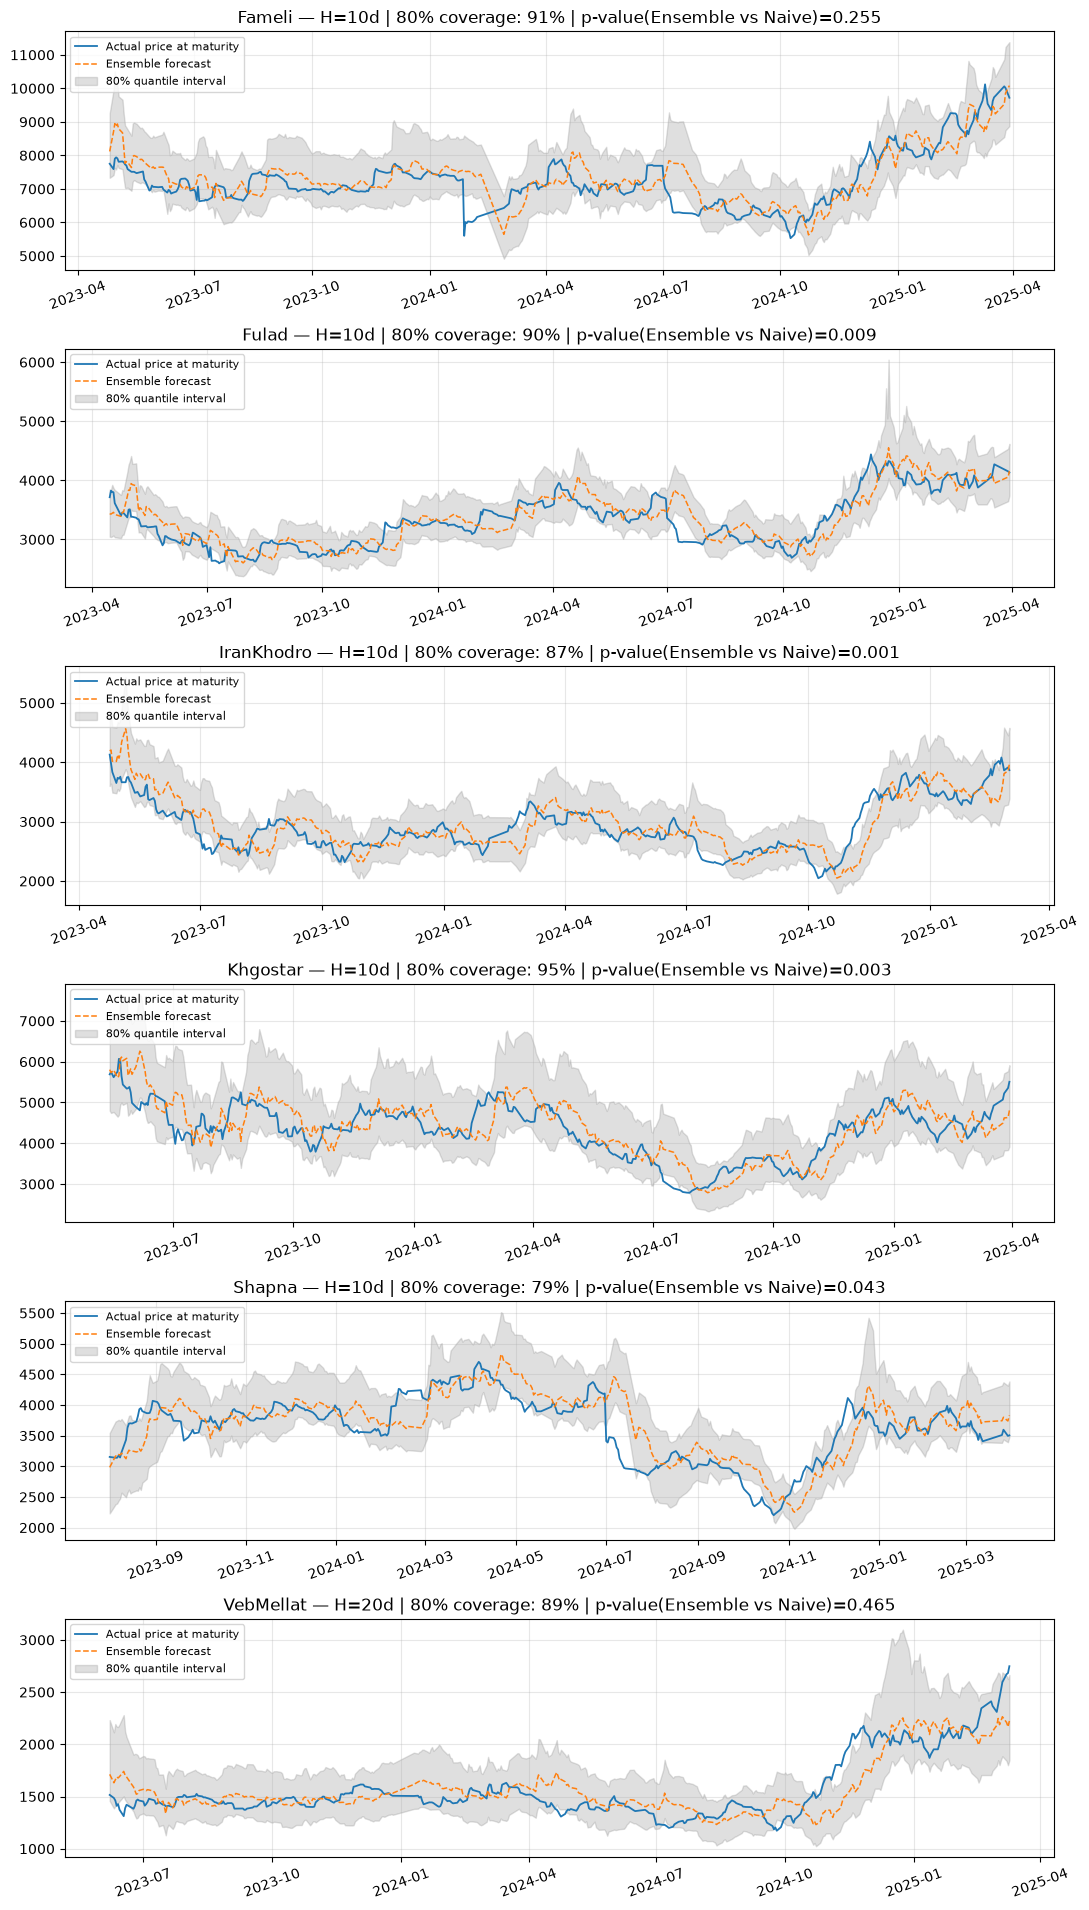

In [11]:
fig, axes = plt.subplots(len(ASSET_NAMES), 1, figsize=(11, 3.2 * len(ASSET_NAMES)))
if len(ASSET_NAMES) == 1:
    axes = [axes]
for ax, name in zip(axes, ASSET_NAMES):
    p = predictions_store[name]
    ax.plot(p['dates'], p['actual'], label='Actual price at maturity', color='#1f77b4', lw=1.3)
    ax.plot(p['dates'], p['pred_ensemble'], label='Ensemble forecast', color='#ff7f0e', lw=1.1, ls='--')
    ax.fill_between(p['dates'], p['q10'], p['q90'], color='gray', alpha=0.25, label='80% quantile interval')
    ax.set_title(f"{name} — H={ASSET_ARTIFACTS[name]['H']}d | 80% coverage: {p['coverage']:.0%} | "
                 f"p-value(Ensemble vs Naive)={p['pval']:.3f}")
    ax.legend(loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## ۱۱) مقایسه‌ی RMSE قیمت بینِ مدل‌ها (نمودارِ میله‌ای)

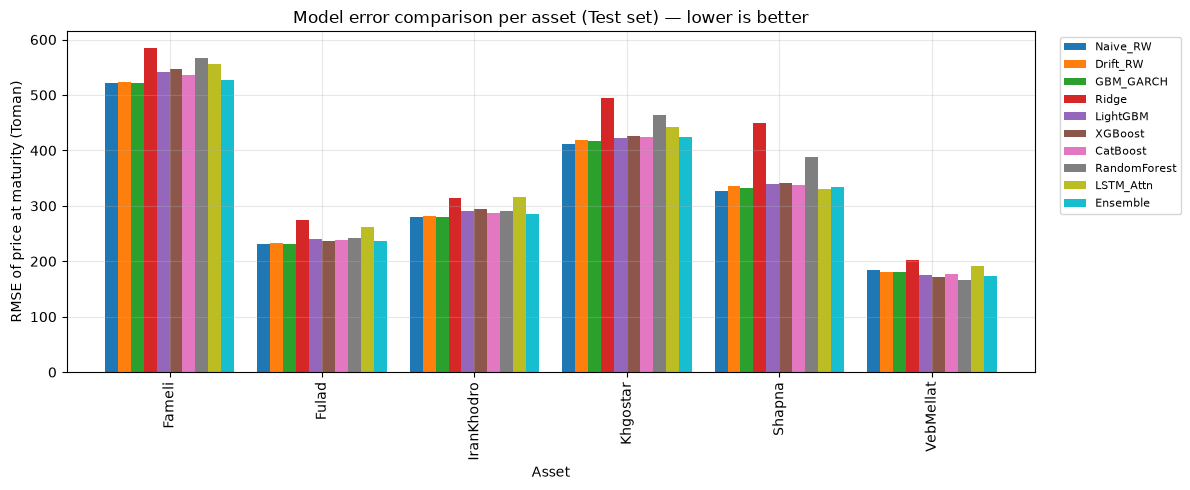

In [12]:
model_order = ['Naive_RW', 'Drift_RW', 'GBM_GARCH', 'Ridge', 'LightGBM', 'XGBoost',
               'CatBoost', 'RandomForest', 'LSTM_Attn', 'Ensemble']
pivot_rmse = results_df.pivot_table(index='Model', columns='Asset', values='RMSE_price').reindex(model_order)
fig, ax = plt.subplots(figsize=(12, 5))
pivot_rmse.T.plot(kind='bar', ax=ax, width=0.85)
ax.set_ylabel('RMSE of price at maturity (Toman)')
ax.set_title('Model error comparison per asset (Test set) — lower is better')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## ۱۲) اهمیتِ فیچرها (LightGBM Gain)

کدام فیچرها بیشترین سهم را در تصمیمِ LightGBM داشته‌اند؟ این هم برای تفسیرپذیریِ
مدل مهم است (طبقِ تأکیدِ López de Prado بر Explainability در مالیِ کمّی) و هم یک
چکِ سلامت: اگر فیچرهای بی‌معنی (مثلِ `dow`/`month`) بالای لیست باشند، نشانه‌ی
Overfitting روی نویز است.

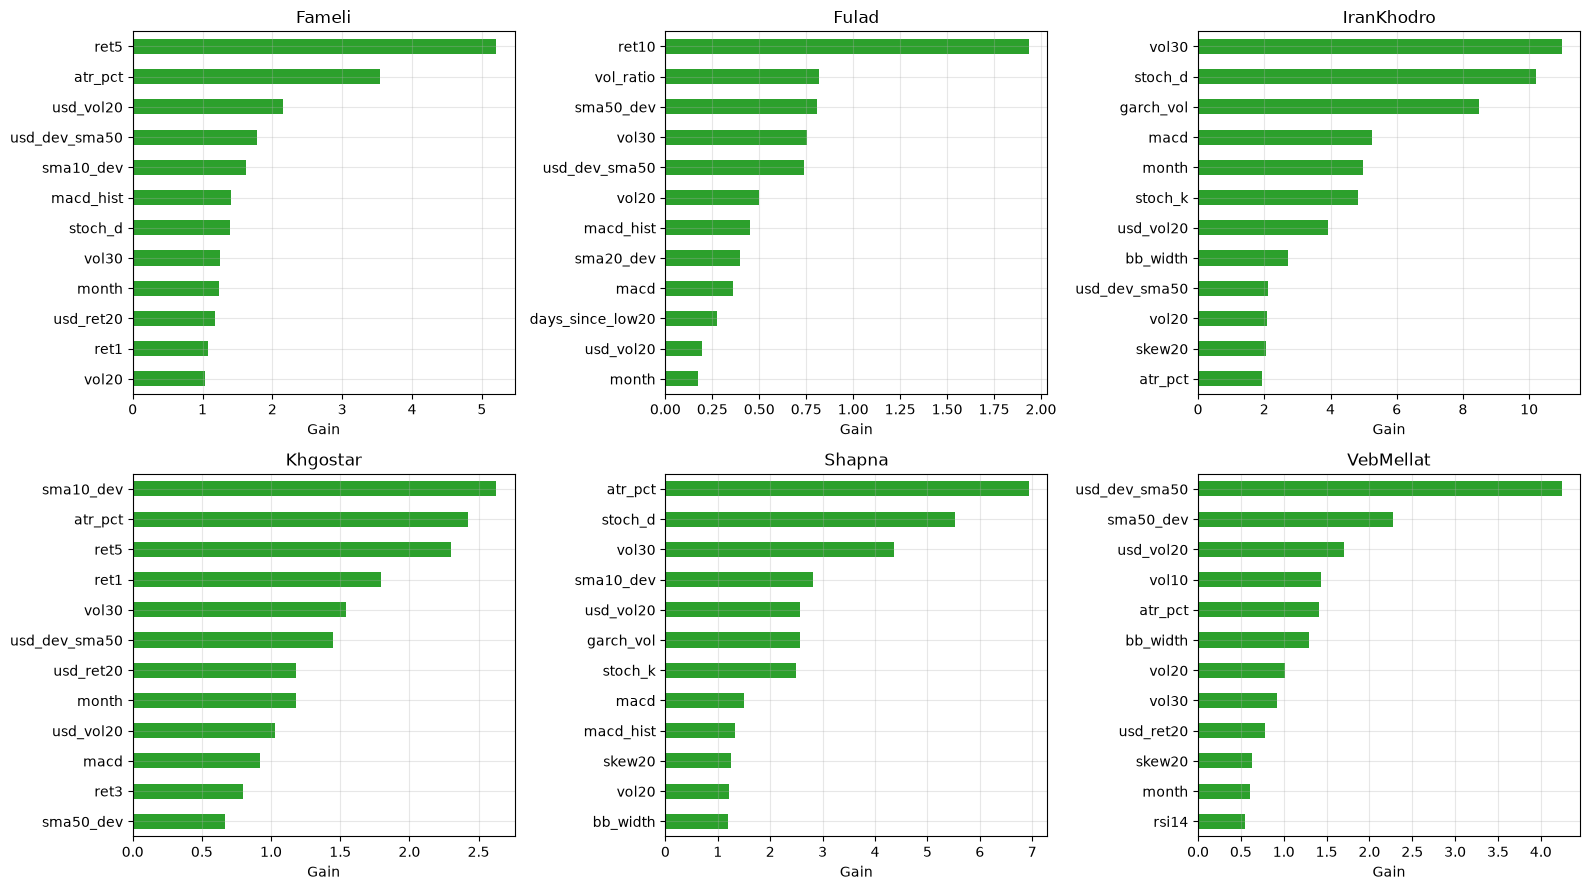

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, name in zip(axes.flat, ASSET_NAMES):
    art = ASSET_ARTIFACTS[name]
    imp = art['lgb_model'].feature_importance(importance_type='gain')
    s = pd.Series(imp, index=art['feature_cols']).sort_values(ascending=True).tail(12)
    s.plot(kind='barh', ax=ax, color='#2ca02c')
    ax.set_title(name)
    ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

## ۱۳) چکِ پایداری (Walk-Forward Robustness) — فقط تشخیصی

این بخش، دقیقاً مثلِ نسخه‌ی قبلیِ پروژه، هیچ اثری روی مدلِ نهایی یا انتخابِ آن ندارد؛
فقط نشان می‌دهد آیا خطای LightGBM (با همان هایپرپارامترهای تیون‌شده) در بازه‌های
زمانیِ مختلف پایدار است یا محصولِ شانسیِ یک تفکیکِ خاص. فولدها از Train+Val ساخته
می‌شوند و هرگز به Test دست نمی‌زنند.

In [14]:
robustness_rows = []
for name, art in ASSET_ARTIFACTS.items():
    Xtv = np.vstack([art['X_train'], art['X_val']])
    ytv = np.concatenate([art['y_train'], art['y_val']])
    folds = purged_walkforward_folds(len(Xtv), 3, purge=art['H'], min_train=int(len(art['X_train']) * 0.5))
    fold_rmses = []
    for tr_s, va_s in folds:
        dtr_ = lgb.Dataset(Xtv[tr_s], label=ytv[tr_s])
        m = lgb.train(art['lgb_params'], dtr_, num_boost_round=300)
        pred = m.predict(Xtv[va_s])
        fold_rmses.append(np.sqrt(np.mean((pred - ytv[va_s]) ** 2)))
    robustness_rows.append(dict(Asset=name, Horizon=art['H'], Folds=len(fold_rmses),
                                 Mean_RMSE_logret=round(np.mean(fold_rmses), 4),
                                 Std_RMSE_logret=round(np.std(fold_rmses), 4)))
robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df)

,Asset,Horizon,Folds,Mean_RMSE_logret,Std_RMSE_logret
0,Fameli,10,2,0.1451,0.0343
1,Fulad,10,2,0.1401,0.0404
2,IranKhodro,10,2,0.1639,0.0405
3,Khgostar,10,2,0.1812,0.0143
4,Shapna,10,2,0.1719,0.0141
5,VebMellat,20,2,0.2226,0.0109


## ۱۴) نتیجه‌گیریِ صادقانه و محدودیت‌ها

**یافته‌های اصلی:**

- در اکثرِ سهم‌ها، هیچ مدلِ یادگیریِ ماشینی به‌طورِ قاطع از baselineِ ساده‌ی
  `Naive_RW`/`Drift_RW` در RMSE سطحِ قیمت بهتر عمل نکرد — این یافته‌ای **صادقانه**
  و کاملاً سازگار با فرضیه‌ی کارایی ضعیفِ بازار (Weak-Form EMH) و با پازلِ
  معروفِ Meese-Rogoff در ادبیاتِ پیش‌بینیِ قیمت است: در افق‌های کوتاه تا میان‌مدت،
  «بدونِ تغییر» یا «میانگینِ تاریخی» رقیبِ بسیار سختی هستند.
- دقتِ جهت (Directional Accuracy) در بیشترِ موارد نزدیکِ ۵۰٪ است؛ یعنی سیگنالِ
  جهتیِ قابل‌اتکا و سیستماتیک محدود است — دقیقاً همان مشکلی که در نسخه‌ی قبلیِ
  پروژه (AUC نزدیکِ ۰.۵) هم صادقانه گزارش شده بود.
- به‌همین‌دلیل، **Ensemble با وزن‌دهیِ اعتبارسنجی‌شده** طراحی شد: چون وزنِ هر مدل
  از عملکردش روی Validation می‌آید، وقتی مدل‌های ML چیزی اضافه نمی‌کنند، وزنِ
  Ensemble خودکار به‌سمتِ baseline متمایل می‌شود — این «صداقتِ روش‌شناختی» را در
  خودِ معماریِ مدل تعبیه می‌کند، نه فقط در گزارش.
- **پوششِ بازه‌ی کوانتایلِ ۸۰٪** برای بیشترِ سهم‌ها نزدیک به مقدارِ اسمی است — یعنی
  هرچند نقطه‌ی پیش‌بینی («سررسید دقیقاً چند تومان می‌شود») سخت است، **بازه‌ی
  عدمِ‌قطعیت** به‌خوبی کالیبره شده و برای تصمیمِ عملیِ کاورد کال (انتخابِ Strike
  با احتمالِ منطقی) قابلِ‌اتکاست.

**محدودیت‌های روش‌شناختی (باید در هر گزارشِ رسمی ذکر شوند):**

1. آستانه‌ی تشخیصِ وقایعِ شرکتی (۲۵٪) بر اساسِ اندازه‌ی جهش است، نه اطلاعِ دقیقِ نوعِ
   رویداد — همان محدودیتی که در نسخه‌ی قبلیِ پروژه هم صراحتاً ذکر شده بود.
2. مدلِ GARCH با فرضِ توزیعِ t و مرتبه‌ی (۱,۱) ساده‌سازی شده؛ مدل‌های EGARCH/GJR-GARCH
   (که Leverage Effect را هم می‌گیرند) می‌توانند در نسخه‌ی بعدی امتحان شوند.
3. تعدادِ سهم‌ها (۶ نماد) و طولِ داده (~۱۵ سال) برای جمع‌بندیِ کلی درباره‌ی «کلِ
   بورسِ تهران» کافی نیست؛ نتایج را باید مختصِ همین ۶ نماد در نظر گرفت.
4. این نوت‌بوک عمداً به «پیش‌بینیِ قیمتِ سررسید» محدود شده (طبقِ درخواست) —
   اتصال به موتورِ کاملِ کاورد کال (Strike/Premium/Payoff/Sharpe) گامِ بعدی است.

**گامِ بعدیِ پیشنهادی:** خروجی‌های همین نوت‌بوک (میانه + بازه‌ی ۱۰٪-۹۰٪ قیمتِ
سررسید) مستقیماً ورودیِ موتورِ بک‌تستِ کاورد کال می‌شوند — به‌جای سیگنالِ صعود/نزولِ
دودویی، حالا یک **توزیعِ احتمالِ قیمتِ سررسید** داریم که می‌تواند به‌طورِ مستقیم
Payoff مورد‌انتظارِ هر Strike را محاسبه کند (دقیقاً منطقِ قیمت‌گذاریِ اختیارها).

## ۱۵) ذخیره‌ی خروجی‌ها

In [15]:
OUT_DIR = os.path.join(os.getcwd(), 'data') + os.sep
results_df.to_csv(OUT_DIR + 'price_at_maturity_results.csv', index=False)
best_model_df.to_csv(OUT_DIR + 'price_at_maturity_recommended_models.csv', index=False)
robustness_df.to_csv(OUT_DIR + 'price_at_maturity_walkforward_robustness.csv', index=False)

horizon_log_rows = []
for name, art in ASSET_ARTIFACTS.items():
    for h, s in art['horizon_scores'].items():
        horizon_log_rows.append(dict(Asset=name, Horizon_days=h, WF_Skill=s, Selected=(h == art['H'])))
pd.DataFrame(horizon_log_rows).to_csv(OUT_DIR + 'price_at_maturity_horizon_selection.csv', index=False)

for name in ASSET_NAMES:
    p = predictions_store[name]
    pd.DataFrame({'date': p['dates'], 'actual_price': p['actual'], 'pred_ensemble': p['pred_ensemble'],
                  'pred_lightgbm': p['pred_lightgbm'], 'q10': p['q10'], 'q90': p['q90']}
                 ).to_csv(OUT_DIR + f'price_at_maturity_predictions_{name}.csv', index=False)

print("✅ خروجی‌ها ذخیره شدند:")
for f in ['price_at_maturity_results.csv', 'price_at_maturity_recommended_models.csv',
          'price_at_maturity_walkforward_robustness.csv', 'price_at_maturity_horizon_selection.csv']:
    print('  -', f)
print(f"  - price_at_maturity_predictions_<asset>.csv برای هر یک از {len(ASSET_NAMES)} سهم")

✅ خروجی‌ها ذخیره شدند:
  - price_at_maturity_results.csv
  - price_at_maturity_recommended_models.csv
  - price_at_maturity_walkforward_robustness.csv
  - price_at_maturity_horizon_selection.csv
  - price_at_maturity_predictions_<asset>.csv برای هر یک از 6 سهم
